<a href="https://colab.research.google.com/github/andreelzs/Linguagens-de-programacao/blob/main/visualizacao_avancada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualização de Dados com Matplotlib - Básico ao Avançado

## Configuração do Ambiente e Dados Iniciais

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)

print("Dataset gerado com sucesso!")
print(f"Período: {df['data'].min().date()} a {df['data'].max().date()}")
print(f"Total de registros: {len(df)}")
print(df.head())

Dataset gerado com sucesso!
Período: 2024-01-01 a 2024-04-29
Total de registros: 120
        data    categoria estado    valor  quantidade  valor_venda
0 2024-01-01       Roupas     BA  2228.06          13      2182.83
1 2024-01-02   Automotivo     RJ  4436.14          12      4538.93
2 2024-01-03  Eletronicos     BA  1127.15          10      1157.60
3 2024-01-04       Roupas     RJ  3041.00           7      2764.45
4 2024-01-05       Roupas     SP  3439.21           9      3352.96


## Parte 1: Gráficos Essenciais e Personalização (Básico)

### Tarefa 1: Gráfico de Linha - Faturamento Mensal

In [2]:
df['data'] = pd.to_datetime(df['data'])
faturamento_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()

print("Faturamento Mensal:")
print(faturamento_mensal)

Faturamento Mensal:
data
2024-01-31    67175.25
2024-02-29    68789.63
2024-03-31    74797.44
2024-04-30    78041.03
Freq: ME, Name: valor_venda, dtype: float64


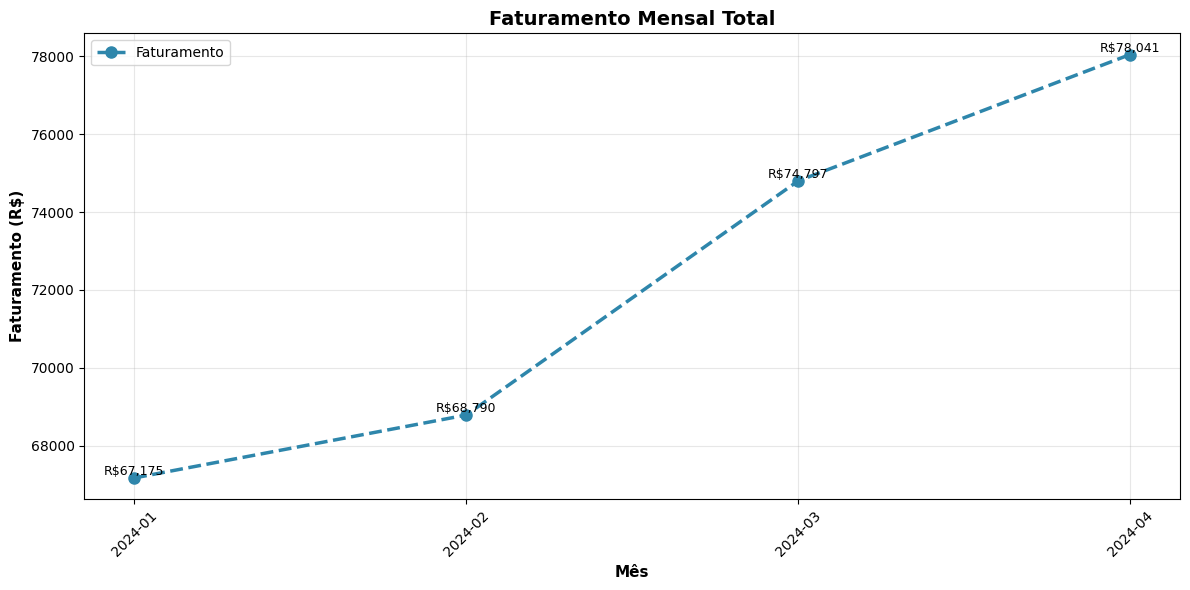

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
meses = [str(mes).split('-')[0:2] for mes in faturamento_mensal.index]
meses_label = [f"{m[0]}-{m[1]}" for m in meses]

ax.plot(range(len(faturamento_mensal)), faturamento_mensal.values,
        marker='o', linestyle='--', color='#2E86AB', linewidth=2.5, markersize=8, label='Faturamento')

ax.set_xlabel('Mês', fontsize=11, fontweight='bold')
ax.set_ylabel('Faturamento (R$)', fontsize=11, fontweight='bold')
ax.set_title('Faturamento Mensal Total', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(faturamento_mensal)))
ax.set_xticklabels(meses_label, rotation=45)
ax.grid(True, alpha=0.3)
ax.legend()

for i, valor in enumerate(faturamento_mensal.values):
    ax.text(i, valor, f'R${valor:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Tarefa 2: Gráfico de Barras - Vendas por Categoria

In [4]:
vendas_categoria = df.groupby('categoria')['valor_venda'].sum().sort_values()

print("Total de Vendas por Categoria:")
print(vendas_categoria)

Total de Vendas por Categoria:
categoria
Eletronicos    52158.89
Roupas         67632.26
Livros         82052.02
Automotivo     86960.18
Name: valor_venda, dtype: float64


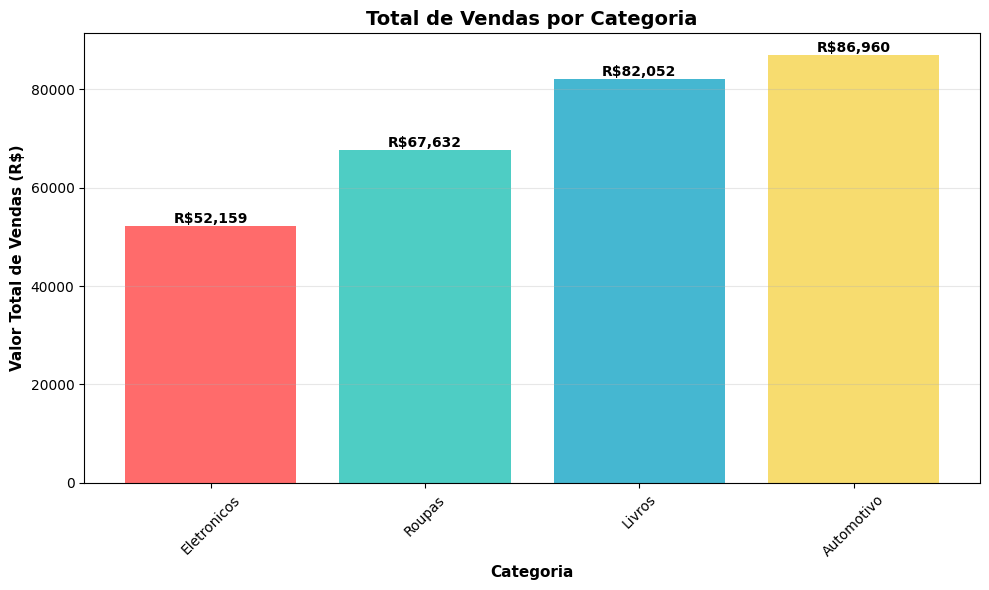

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#F7DC6F']
barras = ax.bar(range(len(vendas_categoria)), vendas_categoria.values, color=cores[:len(vendas_categoria)])

ax.set_xlabel('Categoria', fontsize=11, fontweight='bold')
ax.set_ylabel('Valor Total de Vendas (R$)', fontsize=11, fontweight='bold')
ax.set_title('Total de Vendas por Categoria', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(vendas_categoria)))
ax.set_xticklabels(vendas_categoria.index, rotation=45)
ax.grid(axis='y', alpha=0.3)

for i, (barra, valor) in enumerate(zip(barras, vendas_categoria.values)):
    ax.text(i, valor, f'R${valor:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Tarefa 3: Histograma - Distribuição de Valores

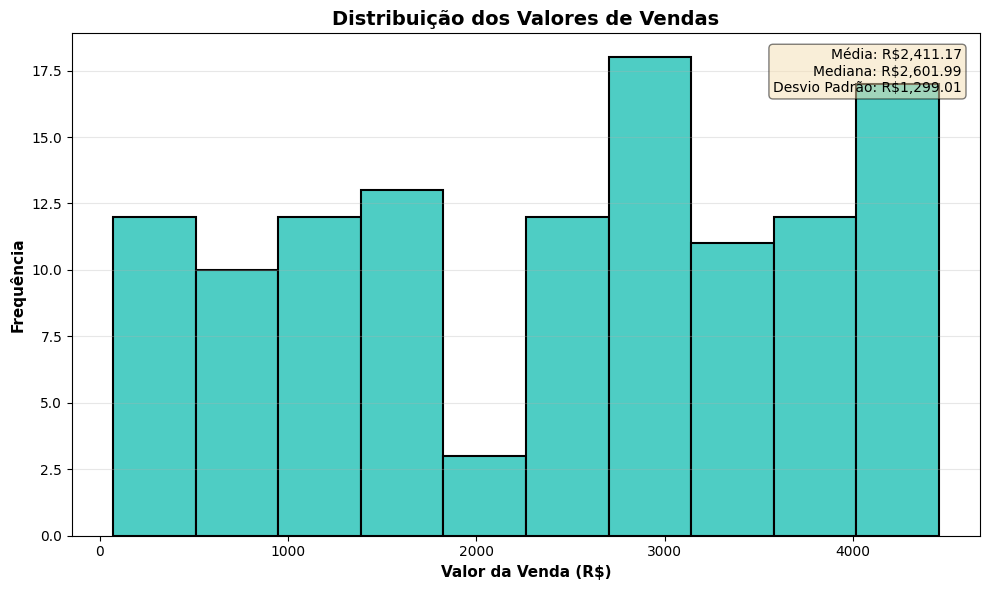

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['valor'], bins=10, color='#4ECDC4', edgecolor='black', linewidth=1.5)

ax.set_xlabel('Valor da Venda (R$)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequência', fontsize=11, fontweight='bold')
ax.set_title('Distribuição dos Valores de Vendas', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

stats = f"Média: R${df['valor'].mean():,.2f}\nMediana: R${df['valor'].median():,.2f}\nDesvio Padrão: R${df['valor'].std():,.2f}"
ax.text(0.98, 0.97, stats, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Parte 2: API Orientada a Objetos e Eixos Múltiplos (Intermediário)

### Tarefa 4: Subplots com Eixo X Compartilhado

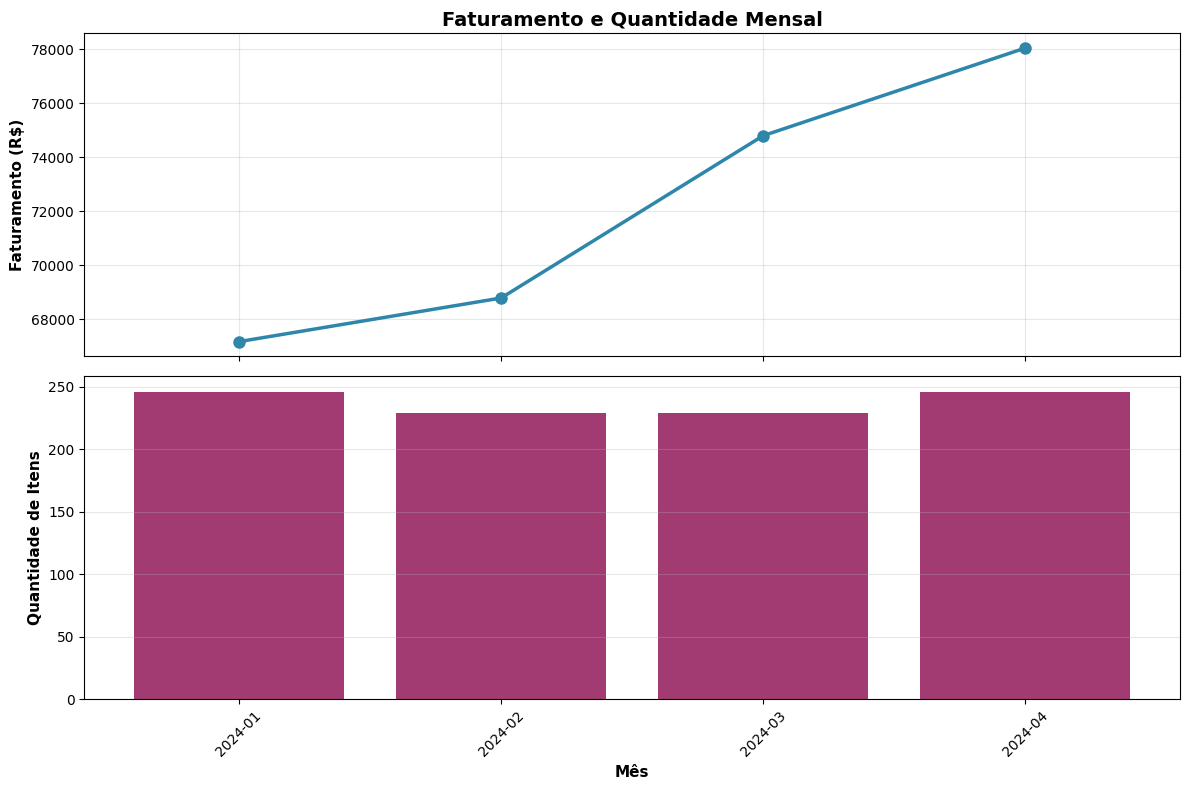

In [7]:
quantidade_mensal = df.set_index('data')['quantidade'].resample('ME').sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(range(len(faturamento_mensal)), faturamento_mensal.values,
         marker='o', color='#2E86AB', linewidth=2.5, markersize=8)
ax1.set_ylabel('Faturamento (R$)', fontsize=11, fontweight='bold')
ax1.set_title('Faturamento e Quantidade Mensal', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.bar(range(len(quantidade_mensal)), quantidade_mensal.values, color='#A23B72')
ax2.set_xlabel('Mês', fontsize=11, fontweight='bold')
ax2.set_ylabel('Quantidade de Itens', fontsize=11, fontweight='bold')
ax2.set_xticks(range(len(faturamento_mensal)))
ax2.set_xticklabels(meses_label, rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Tarefa 5: Eixos Duplos (twinx)

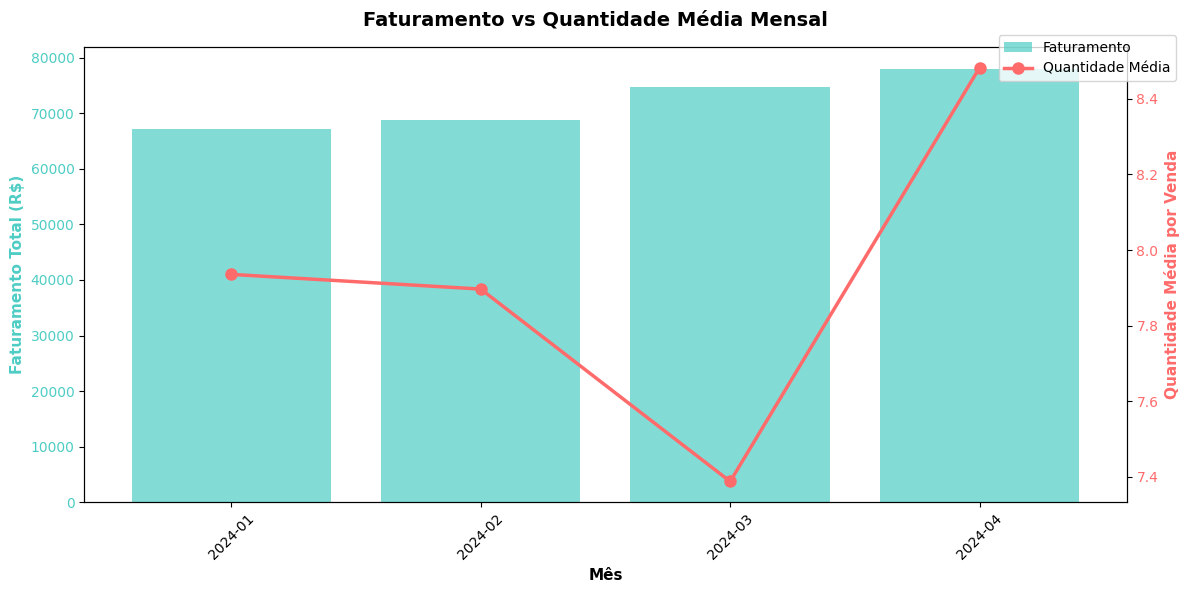

In [8]:
quantidade_media_mensal = df.set_index('data')['quantidade'].resample('ME').mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(range(len(faturamento_mensal)), faturamento_mensal.values, color='#4ECDC4', alpha=0.7, label='Faturamento')
ax1.set_xlabel('Mês', fontsize=11, fontweight='bold')
ax1.set_ylabel('Faturamento Total (R$)', fontsize=11, fontweight='bold', color='#4ECDC4')
ax1.tick_params(axis='y', labelcolor='#4ECDC4')
ax1.set_xticks(range(len(faturamento_mensal)))
ax1.set_xticklabels(meses_label, rotation=45)

ax2 = ax1.twinx()
ax2.plot(range(len(quantidade_media_mensal)), quantidade_media_mensal.values,
         marker='o', color='#FF6B6B', linewidth=2.5, markersize=8, label='Quantidade Média')
ax2.set_ylabel('Quantidade Média por Venda', fontsize=11, fontweight='bold', color='#FF6B6B')
ax2.tick_params(axis='y', labelcolor='#FF6B6B')

fig.suptitle('Faturamento vs Quantidade Média Mensal', fontsize=14, fontweight='bold')
fig.legend(['Faturamento', 'Quantidade Média'], loc='upper right', bbox_to_anchor=(0.99, 0.95))

plt.tight_layout()
plt.show()

### Tarefa 6: Anotação com Seta no Pico de Faturamento

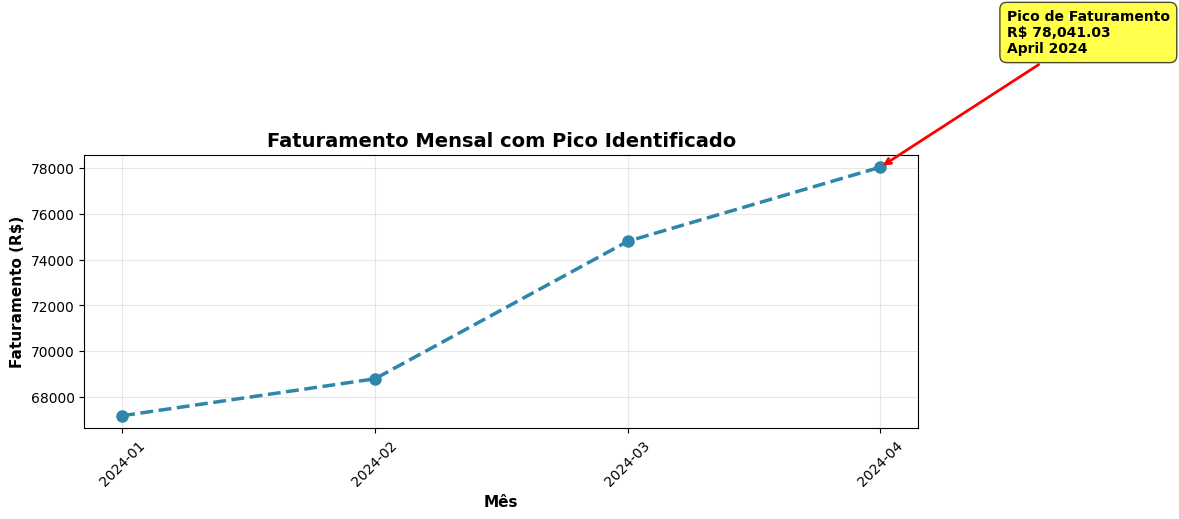

Mês com maior faturamento: April 2024 (R$ 78,041.03)


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(faturamento_mensal)), faturamento_mensal.values,
        marker='o', linestyle='--', color='#2E86AB', linewidth=2.5, markersize=8)

pico_indice = faturamento_mensal.idxmax()
pico_posicao = list(faturamento_mensal.index).index(pico_indice)
pico_valor = faturamento_mensal.max()

ax.annotate(
    f'Pico de Faturamento\nR$ {pico_valor:,.2f}\n{pico_indice.strftime("%B %Y")}',
    xy=(pico_posicao, pico_valor),
    xytext=(pico_posicao + 0.5, pico_valor + 5000),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
    arrowprops=dict(arrowstyle='->', color='red', lw=2)
)

ax.set_xlabel('Mês', fontsize=11, fontweight='bold')
ax.set_ylabel('Faturamento (R$)', fontsize=11, fontweight='bold')
ax.set_title('Faturamento Mensal com Pico Identificado', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(faturamento_mensal)))
ax.set_xticklabels(meses_label, rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mês com maior faturamento: {pico_indice.strftime('%B %Y')} (R$ {pico_valor:,.2f})")

## Parte 3: Matriz de Intensidade / Heatmap (Intermediário/Avançado)

### Tarefa 7 & 8: Heatmap de Vendas por Categoria e Estado

In [10]:
tabela_dinamica = pd.pivot_table(
    df,
    values='valor_venda',
    index='categoria',
    columns='estado',
    aggfunc='sum',
    fill_value=0
)

print("Tabela Dinâmica - Vendas por Categoria e Estado:")
print(tabela_dinamica)
print(f"\nTotal geral: R$ {tabela_dinamica.sum().sum():,.2f}")

Tabela Dinâmica - Vendas por Categoria e Estado:
estado             BA        MG        RJ        RS        SP
categoria                                                    
Automotivo    6992.96  16333.39  26783.38  10122.88  26727.57
Eletronicos  14211.94  13453.06   1154.47  13966.62   9372.80
Livros        4318.03  25667.11   9659.57  19302.59  23104.72
Roupas       26968.88   9876.74  11120.83   4809.04  14856.77

Total geral: R$ 288,803.35


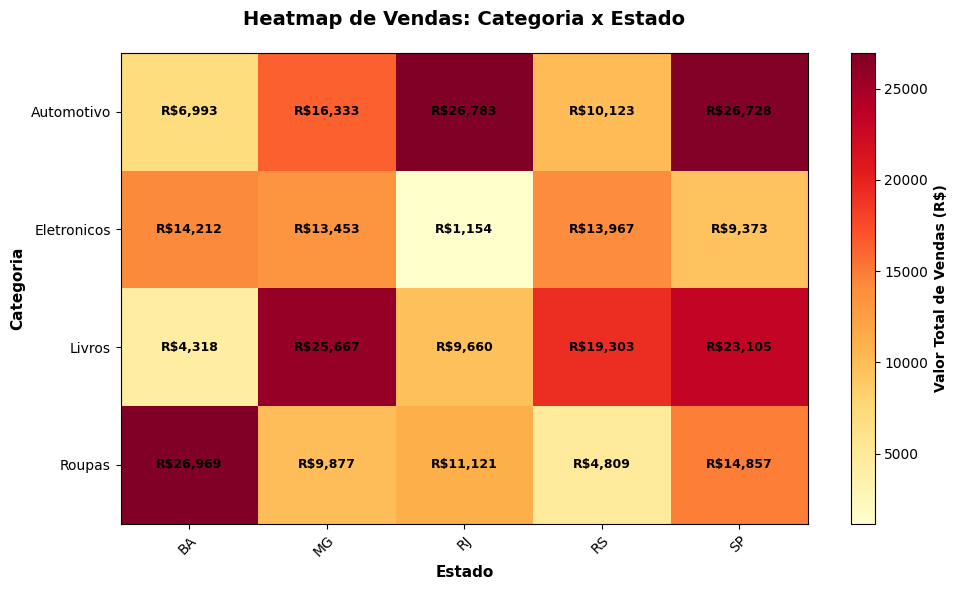

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(tabela_dinamica.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(np.arange(len(tabela_dinamica.columns)))
ax.set_yticks(np.arange(len(tabela_dinamica.index)))
ax.set_xticklabels(tabela_dinamica.columns, fontsize=10)
ax.set_yticklabels(tabela_dinamica.index, fontsize=10)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(len(tabela_dinamica.index)):
    for j in range(len(tabela_dinamica.columns)):
        valor = tabela_dinamica.values[i, j]
        text = ax.text(j, i, f'R${valor:,.0f}',
                      ha="center", va="center", color="black", fontsize=9, fontweight='bold')

ax.set_title('Heatmap de Vendas: Categoria x Estado', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Estado', fontsize=11, fontweight='bold')
ax.set_ylabel('Categoria', fontsize=11, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Valor Total de Vendas (R$)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Tarefa 9: Salvar Heatmap em Arquivo

✓ Arquivo 'heatmap_vendas.png' salvo com sucesso em 300 DPI!


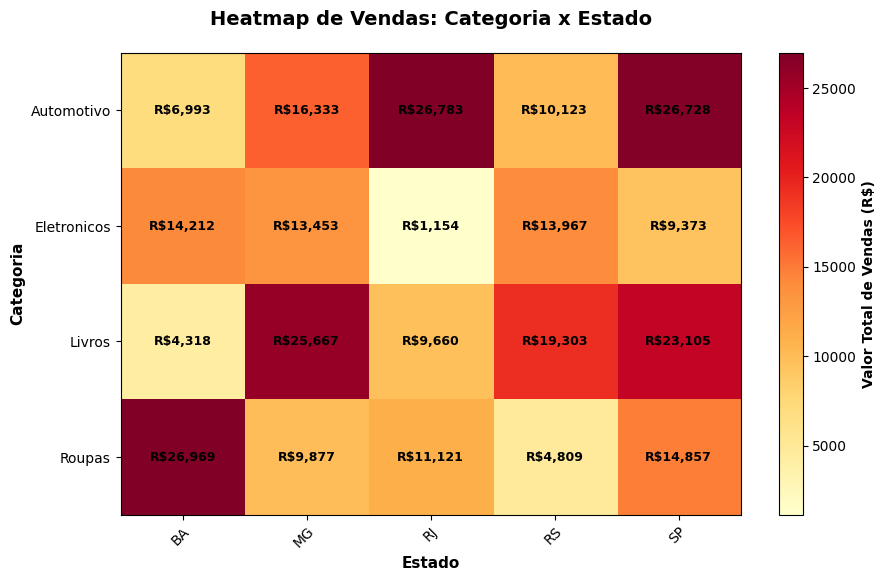

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(tabela_dinamica.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(np.arange(len(tabela_dinamica.columns)))
ax.set_yticks(np.arange(len(tabela_dinamica.index)))
ax.set_xticklabels(tabela_dinamica.columns, fontsize=10)
ax.set_yticklabels(tabela_dinamica.index, fontsize=10)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(len(tabela_dinamica.index)):
    for j in range(len(tabela_dinamica.columns)):
        valor = tabela_dinamica.values[i, j]
        text = ax.text(j, i, f'R${valor:,.0f}',
                      ha="center", va="center", color="black", fontsize=9, fontweight='bold')

ax.set_title('Heatmap de Vendas: Categoria x Estado', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Estado', fontsize=11, fontweight='bold')
ax.set_ylabel('Categoria', fontsize=11, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Valor Total de Vendas (R$)', fontsize=10, fontweight='bold')

plt.savefig('heatmap_vendas.png', dpi=300, bbox_inches='tight')
print("✓ Arquivo 'heatmap_vendas.png' salvo com sucesso em 300 DPI!")

plt.show()

## Resumo Final

In [13]:
print("\n" + "="*70)
print("RESUMO - VISUALIZAÇÃO AVANÇADA COM MATPLOTLIB")
print("="*70)

print(f"\n✓ PARTE 1 - GRÁFICOS ESSENCIAIS:")
print(f"  1. Gráfico de Linha: Faturamento mensal com marcadores e linha tracejada")
print(f"  2. Gráfico de Barras: Vendas por categoria ordenadas (menor → maior)")
print(f"  3. Histograma: Distribuição de valores com 10 bins")

print(f"\n✓ PARTE 2 - API ORIENTADA A OBJETOS:")
print(f"  4. Subplots 2x1: Faturamento e Quantidade com eixo X compartilhado")
print(f"  5. Eixos Duplos (twinx): Faturamento vs Quantidade Média")
print(f"  6. Anotação: Pico identificado com seta e rótulo")

print(f"\n✓ PARTE 3 - HEATMAP:")
print(f"  7. Tabela Dinâmica: Vendas por Categoria x Estado")
print(f"  8. Heatmap renderizado com imshow() e colorbar()")
print(f"  9. Arquivo salvo: 'heatmap_vendas.png' (300 DPI)")

print(f"\n" + "="*70)


RESUMO - VISUALIZAÇÃO AVANÇADA COM MATPLOTLIB

✓ PARTE 1 - GRÁFICOS ESSENCIAIS:
  1. Gráfico de Linha: Faturamento mensal com marcadores e linha tracejada
  2. Gráfico de Barras: Vendas por categoria ordenadas (menor → maior)
  3. Histograma: Distribuição de valores com 10 bins

✓ PARTE 2 - API ORIENTADA A OBJETOS:
  4. Subplots 2x1: Faturamento e Quantidade com eixo X compartilhado
  5. Eixos Duplos (twinx): Faturamento vs Quantidade Média
  6. Anotação: Pico identificado com seta e rótulo

✓ PARTE 3 - HEATMAP:
  7. Tabela Dinâmica: Vendas por Categoria x Estado
  8. Heatmap renderizado com imshow() e colorbar()
  9. Arquivo salvo: 'heatmap_vendas.png' (300 DPI)

